In [1]:
import os
os.chdir("..")  # should be run from repo root
from tqdm import tqdm
from t2i_interp.t2i import T2IModel
from diffusers import AutoPipelineForText2Image
from dictionary_learning.trainers.top_k import AutoEncoderTopK
from t2i_interp.sae import SAEManager
import torch

/home/nirmal/miniconda3/envs/SoftREPA/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/nirmal/miniconda3/envs/SoftREPA/lib/python3.11/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `PYTORCH_TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


NOTE: Training on 25000000 tokens


In [2]:
dtype = torch.float32
device = "cuda:0"

## update sae state_dict to match dictionary_learning implementation

In [ ]:
sd = torch.load(
    "./sdxl-unbox/checkpoints/unet.down_blocks.2.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
    map_location="cuda:0",
)
sd = sd["state_dict"]
sd = {
    k.replace("pre_bias", "b_dec"): v
    for k, v in sd.items()
    if k in ["encoder.weight", "pre_bias", "decoder.weight"]
}
sd.update(
    {"encoder.bias": torch.zeros((5120,)), "k": torch.tensor(10), "threshold": torch.tensor(-1.0)}
)
torch.save(
    sd,
    "./sdxl-unbox/checkpoints/unet.down_blocks.2.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
)

sd = torch.load(
    "./sdxl-unbox/checkpoints/unet.mid_block.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
    map_location="cuda:0",
)
sd = sd["state_dict"]
sd = {
    k.replace("pre_bias", "b_dec"): v
    for k, v in sd.items()
    if k in ["encoder.weight", "pre_bias", "decoder.weight"]
}
sd.update(
    {"encoder.bias": torch.zeros((5120,)), "k": torch.tensor(10), "threshold": torch.tensor(-1.0)}
)
torch.save(
    sd,
    "./sdxl-unbox/checkpoints/unet.mid_block.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
)

sd = torch.load(
    "./sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
    map_location="cuda:0",
)
sd = sd["state_dict"]
sd = {
    k.replace("pre_bias", "b_dec"): v
    for k, v in sd.items()
    if k in ["encoder.weight", "pre_bias", "decoder.weight"]
}
sd.update(
    {"encoder.bias": torch.zeros((5120,)), "k": torch.tensor(10), "threshold": torch.tensor(-1.0)}
)
torch.save(
    sd,
    "./sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
)

sd = torch.load(
    "./sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
    map_location="cuda:0",
)
sd = sd["state_dict"]
sd = {
    k.replace("pre_bias", "b_dec"): v
    for k, v in sd.items()
    if k in ["encoder.weight", "pre_bias", "decoder.weight"]
}
sd.update(
    {"encoder.bias": torch.zeros((5120,)), "k": torch.tensor(10), "threshold": torch.tensor(-1.0)}
)
torch.save(
    sd,
    "./sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
)

## load saes

In [3]:
dtype = torch.float16
sae1 = AutoEncoderTopK.from_pretrained(
    "./sdxl-unbox/checkpoints/unet.down_blocks.2.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
    k=10,
    device=device,
).to(dtype)

sae2= AutoEncoderTopK.from_pretrained(
    "./sdxl-unbox/checkpoints/unet.mid_block.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
    k=10,
    device=device,
    ).to(dtype)
sae3= AutoEncoderTopK.from_pretrained(
    "./sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.0_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
    k=10,
    device=device,
    ).to(dtype)
sae4= AutoEncoderTopK.from_pretrained(
    "./sdxl-unbox/checkpoints/unet.up_blocks.0.attentions.1_k10_hidden5120_auxk256_bs4096_lr0.0001/final/state_dict.pth",
    k=10,
    device=device,
    ).to(dtype)

In [4]:
from t2i_interp.sae import SAEManager

model = T2IModel("stabilityai/sdxl-turbo",automodal=AutoPipelineForText2Image, device=device, dtype="float32")
sae_manager = SAEManager(model=model)
sae1.k = torch.Tensor([5120]).to(device, dtype=dtype)
sae2.k = torch.Tensor([5120]).to(device, dtype=dtype)
sae3.k = torch.Tensor([5120]).to(device, dtype=dtype)
sae4.k = torch.Tensor([5120]).to(device, dtype=dtype)

sae_list=[
    (model.unet.down_blocks_2_attentions_1_out, sae1, "model_unet_down_blocks_2_attentions_1_out"),
    (model.unet.mid_block_attentions_0_out, sae2, "model_unet_mid_block_attentions_0_out"),
    (model.unet.up_blocks_0_attentions_0_out, sae3, "model_unet_up_blocks_0_attentions_0_out"),
    (model.unet.up_blocks_0_attentions_1_out, sae4, "model_unet_up_blocks_0_attentions_1_out"),
]

2026-02-16 20:54:34.530 | INFO     | t2i_interp.t2i:__init__:117 - Loading model stabilityai/sdxl-turbo...
Keyword arguments {'trust_remote_code': False, 'safety_checker': None} are not expected by StableDiffusionXLPipeline and will be ignored.
Loading pipeline components...: 100%|██████████| 7/7 [00:00<00:00,  9.50it/s]


## cache sae activations

In [5]:
from t2i_interp.utils.inference import Inference, InferenceSpec

prompt = "A cinematic shot of a professor sloth wearing a tuxedo at a BBQ party."

# Using capture_activations directly as inference_fn
spec = InferenceSpec(
    inference_fn=sae_manager.capture_activations,
    kwargs={
        "sae_list": sae_list,
        "prompt": prompt,
        "num_inference_steps": 1,
        "guidance_scale": 0.0,
        "seed": 42,
        "use_delta": True,
        "return_images": False # We only want latents in preds
    }
)

inference = Inference(spec)
output = inference.run_inference()
# output.preds is now the dict {name: z_latent}


100%|██████████| 1/1 [00:00<00:00,  3.07it/s]


In [6]:
output.preds['model_unet_down_blocks_2_attentions_1_out'].shape

torch.Size([256, 5120])

## heatmap of top feature activations imposed on image

In [7]:
sparse_maps = output.preds["model_unet_down_blocks_2_attentions_1_out"].view(16,16,-1)
top_features = sparse_maps.mean(axis=(0, 1)).topk(10).indices.cpu().tolist()

# Replaced nnsight generate with direct pipeline call
generator = torch.Generator(device=device).manual_seed(42)
orig = model.pipeline(
    "A cinematic shot of a professor sloth wearing a tuxedo at a BBQ party.",
    num_inference_steps=1,
    generator=generator,
    guidance_scale=0.0,
)
output.images = [orig.images[0]]


100%|██████████| 1/1 [00:00<00:00, 15.37it/s]


In [8]:
top_features   

[2881, 1364, 1226, 2012, 2345, 4690, 4539, 3119, 1899, 4608]

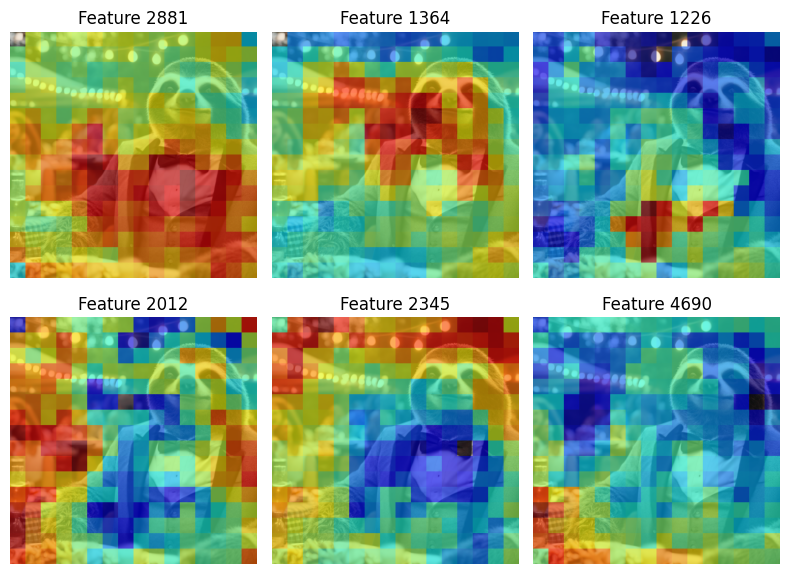

In [10]:
from t2i_interp.utils.plot import plot_image_heatmap
from matplotlib import pyplot as plt

plt.figure(figsize=(8, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(plot_image_heatmap(output, sparse_maps, top_features[i]))
    plt.title(f"Feature {top_features[i]}")
    plt.axis("off")
plt.tight_layout()


## sae steering

In [12]:
from t2i_interp.utils.T2I.policy import scale_indx_policy

def activation_modulation(sparse_maps_unused, sae_name, feature_idx, strength):
    """
    Steers generation by scaling specific feature dimensions.
    args:
        sparse_maps_unused: Unused, kept for compatibility.
        sae_name: name of the SAE in sae_manager
        feature_idx: index of the feature to modulate
        strength: scaling factor (e.g., 0.5 for half, 2.0 for double)
    """
    # Use strength as the scaling factor
    z_alter_fn = scale_indx_policy(strength, [feature_idx])
    
    z_alter_fns = {
        sae_name: z_alter_fn
    }
    
    # Run generation with steering
    images = sae_manager.run_with_steering(
        sae_list,
        prompt,
        z_alter_fns=z_alter_fns,
        use_delta=True,
        num_inference_steps=1,
        guidance_scale=0.0,
        seed=42
    )
    return images[0]


  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 13.10it/s]


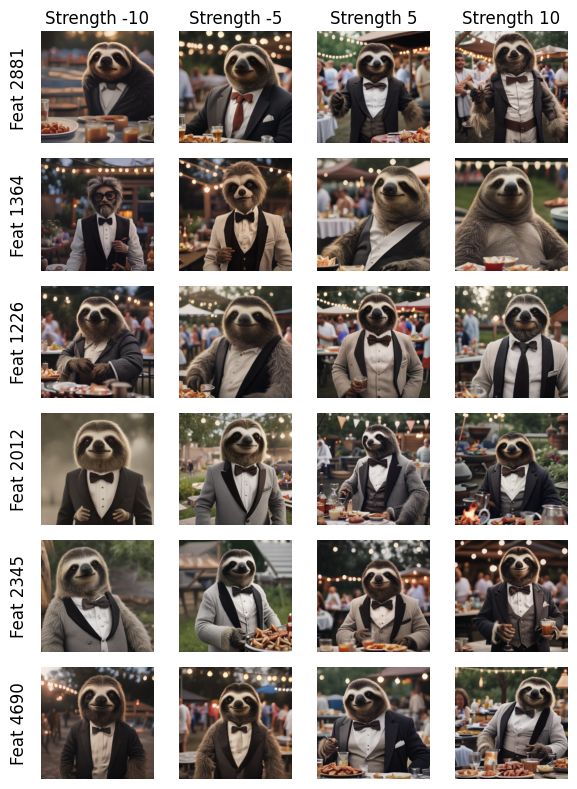

In [14]:
# Plotting grid of steered images
sae_name = "model_unet_down_blocks_2_attentions_1_out"
# Ensure sparse_maps is available and shaped correctly (H, W, D)
# Assuming 'output' from capture_activations is available
if 'output' in locals() and sae_name in output.preds:
    sparse_maps = output.preds[sae_name].view(16, 16, -1)
    
    # Re-calculate top features if not present
    if 'top_features' not in locals():
        top_features = sparse_maps.mean(axis=(0, 1)).topk(10).indices.cpu().tolist()

    plt.figure(figsize=(6, 8))
    strengths = [-10, -5, 5, 10]
    
    # Loop over top 6 features
    for i, feature in enumerate(top_features[:6]):
        for j, strength in enumerate(strengths):
            plt.subplot(6, 4, i*4+j+1)
            plt.axis("off")
            
            img = activation_modulation(sparse_maps, sae_name, feature, strength)
            plt.imshow(img)
            
            if i == 0:
                plt.title(f"Strength {strength}")
            if j == 0:
                plt.text(-0.2, 0.5, f"Feat {feature}", fontsize=12, 
                         ha='center', va='center', rotation=90, transform=plt.gca().transAxes)
    
    plt.tight_layout()
    plt.show()
else:
    print("sparse_maps or output not found. Please run capture_activations cell first.")
